# Adult Income Prediction — Feature Engineering & Cross-Validation (Day 3)

Continuation of Day 1–2: engineered features, a rebuilt pipeline, and stratified 5-fold CV on the **training set only**.

**Primary metric:** F1 (same as Day 1–2). The Day 1 hold-out test set is not used for model selection.

## 1. Setup & Same Hold-Out Split as Day 1

In [1]:
import time
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, FunctionTransformer, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.feature_selection import SelectKBest, mutual_info_classif
from sklearn.base import clone
from scipy import stats

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
RANDOM_STATE = 42

In [2]:
# Same loading / cleaning / split as Day 1 and Day 2
adult = fetch_openml("adult", version=2, as_frame=True, parser="auto")
df = adult.frame.copy()
df = df.rename(columns={"class": "income"})
df = df.replace(r"^\s*\?$", np.nan, regex=True)
df["income"] = df["income"].astype(str).map({"<=50K": 0, ">50K": 1})

X = df.drop("income", axis=1)
y = df["income"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y,
)

print(f"Train: {len(X_train):,} | Test (hold-out, unused for CV): {len(X_test):,}")
print(f"Train positive rate: {y_train.mean() * 100:.2f}%")

Train: 39,073 | Test (hold-out, unused for CV): 9,769
Train positive rate: 23.93%


## 2. Engineered Features

I created **8** features from current-row values only (no target encoding).

### Feature dictionary

In [3]:
FEATURE_DICT = [
    {
        "name": "age_bucket",
        "type": "categorical",
        "rule": "pd.cut(age, bins=[0,25,35,45,55,65,100])",
        "why": "Income rises through mid-career then falls; bins capture that non-linear pattern.",
    },
    {
        "name": "hours_bin",
        "type": "categorical",
        "rule": "pd.cut(hours-per-week, bins=[0,20,40,50,100])",
        "why": "Part-time vs overtime work hours relate differently to >50K than raw hours alone.",
    },
    {
        "name": "has_capital_gain",
        "type": "binary",
        "rule": "(capital-gain > 0).astype(int)",
        "why": "Most people have zero capital-gain; a simple flag separates investors from non-investors.",
    },
    {
        "name": "log_capital_gain",
        "type": "numeric",
        "rule": "np.log1p(capital-gain)",
        "why": "Capital-gain is heavily skewed; log compresses extreme values for linear models.",
    },
    {
        "name": "is_higher_edu",
        "type": "binary",
        "rule": "(education-num >= 13).astype(int)",
        "why": "Matches the Day 1 education rule threshold (Bachelors+), as an explicit feature.",
    },
    {
        "name": "edu_x_hours",
        "type": "numeric",
        "rule": "education-num * hours-per-week",
        "why": "High education with long hours may compound income more than either alone.",
    },
    {
        "name": "has_capital_loss",
        "type": "binary",
        "rule": "(capital-loss > 0).astype(int)",
        "why": "Any capital loss is rare and may signal investment activity linked to higher income.",
    },
    {
        "name": "is_full_time",
        "type": "binary",
        "rule": "(hours-per-week >= 40).astype(int)",
        "why": "Full-time work is a simple threshold often used in labor economics.",
    },
]

pd.DataFrame(FEATURE_DICT)

,name,type,rule,why
0,age_bucket,categorical,"pd.cut(age, bins=[0,25,35,45,55,65,100])",Income rises through mid-career then falls; bi...
1,hours_bin,categorical,"pd.cut(hours-per-week, bins=[0,20,40,50,100])",Part-time vs overtime work hours relate differ...
2,has_capital_gain,binary,(capital-gain > 0).astype(int),Most people have zero capital-gain; a simple f...
3,log_capital_gain,numeric,np.log1p(capital-gain),Capital-gain is heavily skewed; log compresses...
4,is_higher_edu,binary,(education-num >= 13).astype(int),Matches the Day 1 education rule threshold (Ba...
5,edu_x_hours,numeric,education-num * hours-per-week,High education with long hours may compound in...
6,has_capital_loss,binary,(capital-loss > 0).astype(int),Any capital loss is rare and may signal invest...
7,is_full_time,binary,(hours-per-week >= 40).astype(int),Full-time work is a simple threshold often use...


In [4]:
def engineer_features(X_df):
    """Add engineered columns using only current-row values (no leakage)."""
    X_out = X_df.copy()
    age = X_out["age"].astype(float)
    hours = X_out["hours-per-week"].astype(float)
    edu = X_out["education-num"].astype(float)
    cg = X_out["capital-gain"].astype(float)
    cl = X_out["capital-loss"].astype(float)

    X_out["age_bucket"] = pd.cut(
        age,
        bins=[0, 25, 35, 45, 55, 65, 100],
        labels=["<=25", "26-35", "36-45", "46-55", "56-65", "65+"],
        include_lowest=True,
    ).astype(str)

    X_out["hours_bin"] = pd.cut(
        hours,
        bins=[0, 20, 40, 50, 100],
        labels=["part_time", "full_time", "overtime", "extreme"],
        include_lowest=True,
    ).astype(str)

    X_out["has_capital_gain"] = (cg > 0).astype(int)
    X_out["log_capital_gain"] = np.log1p(cg)
    X_out["is_higher_edu"] = (edu >= 13).astype(int)
    X_out["edu_x_hours"] = edu * hours
    X_out["has_capital_loss"] = (cl > 0).astype(int)
    X_out["is_full_time"] = (hours >= 40).astype(int)
    return X_out


X_train_eng = engineer_features(X_train)
eng_cols = [d["name"] for d in FEATURE_DICT]
X_train_eng[eng_cols].head()

,age_bucket,hours_bin,has_capital_gain,log_capital_gain,is_higher_edu,edu_x_hours,has_capital_loss,is_full_time
34342,65+,part_time,0,0.0,0,153.0,0,0
18559,<=25,part_time,0,0.0,0,60.0,0,0
12477,26-35,full_time,0,0.0,0,360.0,0,1
560,36-45,full_time,0,0.0,0,360.0,0,1
3427,26-35,full_time,0,0.0,1,520.0,0,1


In [5]:
# Univariate predictive signal on TRAIN only (mutual information + grouped target mean)
rows = []
for col in eng_cols:
    series = X_train_eng[col]
    if series.dtype == object:
        encoded = LabelEncoder().fit_transform(series.astype(str))
        mi = mutual_info_classif(encoded.reshape(-1, 1), y_train, random_state=RANDOM_STATE)[0]
        gm = y_train.groupby(series).mean()
        signal = f"MI={mi:.3f}; >50K rate spread={gm.max() - gm.min():.3f}"
        detail = ", ".join(f"{k}:{v:.2f}" for k, v in gm.sort_values(ascending=False).items())
    else:
        mi = mutual_info_classif(X_train_eng[[col]], y_train, random_state=RANDOM_STATE)[0]
        if set(series.unique()).issubset({0, 1}):
            pos = y_train[series == 1].mean()
            neg = y_train[series == 0].mean()
            signal = f"MI={mi:.3f}; rate 1={pos:.3f} vs 0={neg:.3f}"
            detail = f"delta={pos - neg:.3f}"
        else:
            q = pd.qcut(series, q=5, duplicates="drop")
            gm = y_train.groupby(q, observed=True).mean()
            signal = f"MI={mi:.3f}; quintile spread={gm.max() - gm.min():.3f}"
            detail = f"min={gm.min():.2f}, max={gm.max():.2f}"

    why = next(d["why"] for d in FEATURE_DICT if d["name"] == col)
    rows.append({
        "feature": col,
        "justification": why,
        "univariate_signal": signal,
        "detail": detail,
    })

feature_scores = pd.DataFrame(rows)
feature_scores

,feature,justification,univariate_signal,detail
0,age_bucket,Income rises through mid-career then falls; bi...,MI=0.063; >50K rate spread=0.372,"46-55:0.39, 36-45:0.35, 56-65:0.32, 65+:0.19, ..."
1,hours_bin,Part-time vs overtime work hours relate differ...,MI=0.038; >50K rate spread=0.334,"extreme:0.41, overtime:0.40, full_time:0.19, p..."
2,has_capital_gain,Most people have zero capital-gain; a simple f...,MI=0.032; rate 1=0.615 vs 0=0.206,delta=0.409
3,log_capital_gain,Capital-gain is heavily skewed; log compresses...,MI=0.084; quintile spread=0.000,"min=0.24, max=0.24"
4,is_higher_edu,Matches the Day 1 education rule threshold (Ba...,MI=0.052; rate 1=0.480 vs 0=0.160,delta=0.320
5,edu_x_hours,High education with long hours may compound in...,MI=0.081; quintile spread=0.452,"min=0.06, max=0.51"
6,has_capital_loss,Any capital loss is rare and may signal invest...,MI=0.012; rate 1=0.504 vs 0=0.226,delta=0.278
7,is_full_time,Full-time work is a simple threshold often use...,MI=0.026; rate 1=0.285 vs 0=0.094,delta=0.190


`log_capital_gain` and `edu_x_hours` have the strongest mutual information (~0.08). People with capital gain are >50K much more often (0.62 vs 0.21). For age buckets, the >50K rate peaks around ages 46–55 (~39%) and is very low for <=25 (~2%).

## 3. Pipeline with Engineered Features

`FunctionTransformer` adds the new columns inside the pipeline so every CV fold uses the same steps. Imputers and scalers still fit on training folds only.

### Preprocessing choices

- **Median imputation** for numerics (not mean) — capital-gain/loss are skewed.
- **Constant `"Missing"`** for categoricals (not dropping rows) — keeps sample size and makes missingness explicit.
- **OneHotEncoder** (not LabelEncoder) — categories have no natural order.
- **No target encoding** — it needs careful nested CV to avoid leakage, so I left it for later if needed.
- **Row-level features only** — no fold-global stats beyond fixed bin edges.
- Kept both `education` and `education-num` for now; Day 4 can drop one after tuning starts.

In [6]:
BASE_NUMERIC = [
    "age", "fnlwgt", "education-num", "capital-gain", "capital-loss", "hours-per-week",
]
ENG_NUMERIC = [
    "log_capital_gain", "edu_x_hours", "has_capital_gain",
    "is_higher_edu", "has_capital_loss", "is_full_time",
]
BASE_CATEGORICAL = [
    "workclass", "education", "marital-status", "occupation",
    "relationship", "race", "sex", "native-country",
]
ENG_CATEGORICAL = ["age_bucket", "hours_bin"]

ALL_NUMERIC = BASE_NUMERIC + ENG_NUMERIC
ALL_CATEGORICAL = BASE_CATEGORICAL + ENG_CATEGORICAL


def make_preprocessor():
    numeric_pipeline = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ])
    categorical_pipeline = Pipeline([
        ("imputer", SimpleImputer(strategy="constant", fill_value="Missing")),
        ("encoder", OneHotEncoder(handle_unknown="ignore")),
    ])
    # sparse_threshold=0 -> dense matrix (needed by HistGradientBoosting)
    return ColumnTransformer(
        [
            ("num", numeric_pipeline, ALL_NUMERIC),
            ("cat", categorical_pipeline, ALL_CATEGORICAL),
        ],
        sparse_threshold=0,
    )


engineer = FunctionTransformer(engineer_features, validate=False)


def make_model_pipeline(estimator):
    return Pipeline([
        ("engineer", engineer),
        ("preprocess", make_preprocessor()),
        ("clf", estimator),
    ])


print("Numeric columns:", ALL_NUMERIC)
print("Categorical columns:", ALL_CATEGORICAL)

Numeric columns: ['age', 'fnlwgt', 'education-num', 'capital-gain', 'capital-loss', 'hours-per-week', 'log_capital_gain', 'edu_x_hours', 'has_capital_gain', 'is_higher_edu', 'has_capital_loss', 'is_full_time']
Categorical columns: ['workclass', 'education', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'native-country', 'age_bucket', 'hours_bin']


## 4. Cross-Validated Model Comparison

Stratified 5-fold CV on **training data only**. Models: Logistic Regression, Random Forest, HistGradientBoosting.

In [7]:
models = {
    "Logistic Regression": LogisticRegression(
        random_state=RANDOM_STATE, solver="lbfgs", max_iter=2000
    ),
    "Random Forest": RandomForestClassifier(
        random_state=RANDOM_STATE, n_estimators=100, n_jobs=-1
    ),
    "HistGradientBoosting": HistGradientBoostingClassifier(
        random_state=RANDOM_STATE, max_iter=100
    ),
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

cv_rows = []
fold_scores = {}  # for paired tests and boxplots

for name, clf in models.items():
    pipe = make_model_pipeline(clone(clf))
    t0 = time.time()
    scores = cross_validate(
        pipe,
        X_train,
        y_train,
        cv=cv,
        scoring={"f1": "f1", "roc_auc": "roc_auc", "accuracy": "accuracy"},
        n_jobs=-1,
    )
    elapsed = time.time() - t0
    fold_scores[name] = {
        "f1": scores["test_f1"],
        "roc_auc": scores["test_roc_auc"],
    }
    cv_rows.append({
        "Model": name,
        "F1 mean": scores["test_f1"].mean(),
        "F1 std": scores["test_f1"].std(),
        "ROC AUC mean": scores["test_roc_auc"].mean(),
        "ROC AUC std": scores["test_roc_auc"].std(),
        "Accuracy mean": scores["test_accuracy"].mean(),
        "CV time (s)": elapsed,
    })
    print(
        f"{name}: F1={scores['test_f1'].mean():.4f}±{scores['test_f1'].std():.4f} | "
        f"AUC={scores['test_roc_auc'].mean():.4f}±{scores['test_roc_auc'].std():.4f} | "
        f"{elapsed:.1f}s"
    )

cv_table = pd.DataFrame(cv_rows).set_index("Model")
cv_table.round(4)

Logistic Regression: F1=0.6755±0.0108 | AUC=0.9136±0.0033 | 7.2s


Random Forest: F1=0.6616±0.0085 | AUC=0.9009±0.0047 | 15.7s


HistGradientBoosting: F1=0.7084±0.0094 | AUC=0.9273±0.0026 | 13.3s


,F1 mean,F1 std,ROC AUC mean,ROC AUC std,Accuracy mean,CV time (s)
Model,,,,,,
Logistic Regression,0.6755,0.0108,0.9136,0.0033,0.8578,7.1926
Random Forest,0.6616,0.0085,0.9009,0.0047,0.8503,15.7000
HistGradientBoosting,0.7084,0.0094,0.9273,0.0026,0.8719,13.2671


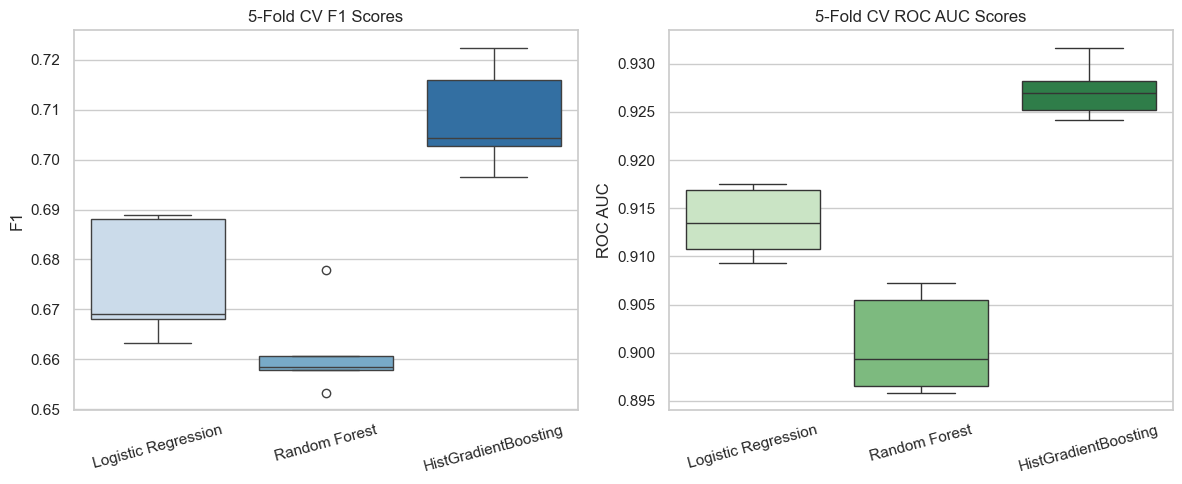

In [8]:
# Boxplots of fold F1 and ROC AUC
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

f1_df = pd.DataFrame({k: v["f1"] for k, v in fold_scores.items()})
auc_df = pd.DataFrame({k: v["roc_auc"] for k, v in fold_scores.items()})

sns.boxplot(data=f1_df, ax=axes[0], palette="Blues")
axes[0].set_title("5-Fold CV F1 Scores")
axes[0].set_ylabel("F1")
axes[0].tick_params(axis="x", rotation=15)

sns.boxplot(data=auc_df, ax=axes[1], palette="Greens")
axes[1].set_title("5-Fold CV ROC AUC Scores")
axes[1].set_ylabel("ROC AUC")
axes[1].tick_params(axis="x", rotation=15)

plt.tight_layout()
plt.show()

## 5. Statistical Comparison and Feature Importance

In [9]:
# Top 2 models by mean F1
ranked = cv_table["F1 mean"].sort_values(ascending=False)
top1, top2 = ranked.index[0], ranked.index[1]
f1_a = fold_scores[top1]["f1"]
f1_b = fold_scores[top2]["f1"]

t_stat, t_p = stats.ttest_rel(f1_a, f1_b)
# Wilcoxon needs non-zero differences; with 5 folds it is underpowered
try:
    w_stat, w_p = stats.wilcoxon(f1_a, f1_b)
except ValueError:
    w_stat, w_p = np.nan, np.nan

diff = f1_a.mean() - f1_b.mean()
print(f"Top models: {top1} vs {top2}")
print(f"Mean F1 difference: {diff:.4f}")
print(f"Paired t-test: t={t_stat:.3f}, p={t_p:.4f}")
print(f"Wilcoxon signed-rank: W={w_stat}, p={w_p:.4f}")
print()
if t_p < 0.05:
    print(
        f"Paired t-test: the F1 gap ({diff:.3f}) looks significant (p={t_p:.4f}). "
        f"Wilcoxon is weaker with only 5 folds (p={w_p:.3f}), but HGB led on every fold."
    )
else:
    print("The F1 difference is not clearly significant; either model could be tuned next.")

Top models: HistGradientBoosting vs Logistic Regression
Mean F1 difference: 0.0329
Paired t-test: t=22.375, p=0.0000
Wilcoxon signed-rank: W=0.0, p=0.0625

Paired t-test: the F1 gap (0.033) looks significant (p=0.0000). Wilcoxon is weaker with only 5 folds (p=0.062), but HGB led on every fold.


In [10]:
# Fit RF and LR on full training set for importances / coefficients
rf_pipe = make_model_pipeline(clone(models["Random Forest"]))
lr_pipe = make_model_pipeline(clone(models["Logistic Regression"]))
hgb_pipe = make_model_pipeline(clone(models["HistGradientBoosting"]))

rf_pipe.fit(X_train, y_train)
lr_pipe.fit(X_train, y_train)
hgb_pipe.fit(X_train, y_train)

feature_names = lr_pipe.named_steps["preprocess"].get_feature_names_out()
ENG_KEYS = [
    "age_bucket", "hours_bin", "has_capital_gain", "log_capital_gain",
    "is_higher_edu", "edu_x_hours", "has_capital_loss", "is_full_time",
]
eng_mask = pd.Series(feature_names).str.contains("|".join(ENG_KEYS))

# Random Forest importances for engineered columns
rf_imp = pd.DataFrame({
    "feature": feature_names,
    "importance": rf_pipe.named_steps["clf"].feature_importances_,
})
rf_eng = rf_imp[eng_mask.values].sort_values("importance", ascending=False)
print("=== Random Forest — engineered feature importances ===")
display(rf_eng.head(15).round(4))

=== Random Forest — engineered feature importances ===


,feature,importance
7,num__edu_x_hours,0.0621
6,num__log_capital_gain,0.0467
9,num__is_higher_edu,0.0311
8,num__has_capital_gain,0.0146
119,cat__age_bucket_<=25,0.0090
116,cat__age_bucket_46-55,0.0089
115,cat__age_bucket_36-45,0.0085
114,cat__age_bucket_26-35,0.0074
10,num__has_capital_loss,0.0072
11,num__is_full_time,0.0061


In [11]:
# Logistic Regression coefficients for engineered columns (itemized)
lr_coef = pd.DataFrame({
    "feature": feature_names,
    "coefficient": lr_pipe.named_steps["clf"].coef_[0],
})
lr_eng = lr_coef[eng_mask.values].copy()
lr_eng["abs_coef"] = lr_eng["coefficient"].abs()
lr_eng = lr_eng.sort_values("abs_coef", ascending=False)
print("=== Logistic Regression — engineered coefficients ===")
display(lr_eng.round(4))

=== Logistic Regression — engineered coefficients ===


,feature,coefficient,abs_coef
6,num__log_capital_gain,6.0433,6.0433
8,num__has_capital_gain,-5.6738,5.6738
118,cat__age_bucket_65+,-0.8929,0.8929
119,cat__age_bucket_<=25,-0.7862,0.7862
123,cat__hours_bin_part_time,-0.6831,0.6831
10,num__has_capital_loss,-0.5346,0.5346
115,cat__age_bucket_36-45,0.4471,0.4471
116,cat__age_bucket_46-55,0.4049,0.4049
7,num__edu_x_hours,-0.3185,0.3185
121,cat__hours_bin_full_time,-0.2718,0.2718


### Notes on engineered-feature coefficients

Positive coefficients push toward >50K; negative ones push toward <=50K.

1. **`log_capital_gain` (large +):** Higher logged capital-gain strongly raises predicted >50K — similar to the Day 1 TP vs FP gap on capital-gain.
2. **`has_capital_gain` (large − with log present):** Once the log amount is in the model, the flag often gets an opposite sign because the two columns overlap. Together they still capture “any gain + how much.”
3. **`age_bucket_<=25` (−):** Younger adults are less often >50K.
4. **`age_bucket_65+` (−):** The oldest group also has a lower >50K rate.
5. **`age_bucket_36-45` / `46-55` (+):** Peak earning ages.
6. **`hours_bin_part_time` (−):** Part-time work linked to lower income predictions.
7. **`hours_bin_overtime` (+):** Longer hours linked to higher income.
8. **`has_capital_loss`:** Weaker in LR, but RF still uses it as a rare-event flag.
9. **`edu_x_hours`:** Important in RF; smaller in LR after scaling and correlated education/hours terms.
10. **`is_higher_edu`:** Still useful; overlaps with `education-num` and the Day 1 rule.

**Which engineered features mattered most?**  
RF: `edu_x_hours`, `log_capital_gain`, `is_higher_edu`.  
LR: `log_capital_gain` / `has_capital_gain`, age buckets, hours bins.  
That matches Day 1 error analysis — education alone was not enough without hours, capital activity, and life-stage signals.

## 6. Feature Selection Check

Compare the full feature set vs `SelectKBest` (mutual information) on HistGradientBoosting, measuring CV F1 and wall-clock time.

In [12]:
def make_selected_pipeline(estimator, k=None):
    steps = [
        ("engineer", engineer),
        ("preprocess", make_preprocessor()),
    ]
    if k is not None:
        steps.append(("select", SelectKBest(score_func=mutual_info_classif, k=k)))
    steps.append(("clf", clone(estimator)))
    return Pipeline(steps)


selection_rows = []
for label, k in [("All features", None), ("SelectKBest k=100", 100), ("SelectKBest k=50", 50)]:
    pipe = make_selected_pipeline(
        HistGradientBoostingClassifier(random_state=RANDOM_STATE, max_iter=100),
        k=k,
    )
    t0 = time.time()
    scores = cross_validate(
        pipe, X_train, y_train, cv=cv,
        scoring={"f1": "f1", "roc_auc": "roc_auc"},
        n_jobs=-1,
    )
    elapsed = time.time() - t0
    selection_rows.append({
        "Setup": label,
        "F1 mean": scores["test_f1"].mean(),
        "F1 std": scores["test_f1"].std(),
        "ROC AUC mean": scores["test_roc_auc"].mean(),
        "CV time (s)": elapsed,
    })
    print(f"{label}: F1={scores['test_f1'].mean():.4f}±{scores['test_f1'].std():.4f} | {elapsed:.1f}s")

selection_table = pd.DataFrame(selection_rows).set_index("Setup")
selection_table.round(4)

All features: F1=0.7084±0.0094 | 13.6s


SelectKBest k=100: F1=0.7088±0.0092 | 76.7s


SelectKBest k=50: F1=0.6990±0.0066 | 68.2s


,F1 mean,F1 std,ROC AUC mean,CV time (s)
Setup,,,,
All features,0.7084,0.0094,0.9273,13.5933
SelectKBest k=100,0.7088,0.0092,0.9277,76.7195
SelectKBest k=50,0.6990,0.0066,0.9255,68.2433


### What I will keep for Day 4

- Keep all 8 engineered features — they have clear univariate signal, and both RF and LR use several of them.
- Keep the full feature set for HistGradientBoosting. `SelectKBest k=50` lowered CV F1; `k=100` was almost the same as the full set but slower.
- Primary model for Day 4: HistGradientBoosting (best CV F1 and AUC).
- Secondary: Logistic Regression — still strong and easier to interpret; good for trying `class_weight='balanced'` and checking education redundancy.
- Hold-out test set stays unused until after tuning.

In [13]:
# Save artifacts for Day 4
joblib.dump(hgb_pipe, "hgb_engineered_pipeline.joblib")
joblib.dump(make_preprocessor(), "preprocessor_engineered.joblib")
joblib.dump(FEATURE_DICT, "feature_dictionary.joblib")
print("Saved hgb_engineered_pipeline.joblib, preprocessor_engineered.joblib, feature_dictionary.joblib")

Saved hgb_engineered_pipeline.joblib, preprocessor_engineered.joblib, feature_dictionary.joblib


## 7. Conclusion

The new features — especially capital-gain transforms, education×hours, and age/hours bins — helped beyond Day 2's raw columns. On 5-fold CV, HistGradientBoosting had the best F1 and ROC AUC. Feature selection did not clearly beat the full set, so Day 4 tuning will use the full engineered pipeline and focus on HGB, with logistic regression as a fast backup.